In [ ]:
import sklearn
from sklearn import svm
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
print("Sklearn verion is {}".format(sklearn.__version__))

Sklearn verion is 1.2.2


In [ ]:
# 导入数据
df = pd.read_csv('data.csv')
#  数据分析
num_size = 0.7                       # 训练集占数据集比例
outdim = 1                         # 最后一列为输出
num_samples = df.shape[0]                  # 样本个数
random_indices = np.random.permutation(num_samples)     # 生成随机排列的索引
df = df.iloc[random_indices, :]               # 根据随机排列的索引打乱数据集（不希望打乱时，注释该行）
num_train_s = round(num_size * num_samples)        # 训练集样本个数
f_ = df.shape[1] - outdim                 # 输入特征维度

In [ ]:
#  划分训练集和测试集
P_train = df.iloc[:num_train_s, :f_]
p_train = np.array(P_train)
T_train = df.iloc[:num_train_s, f_:]
T_train_flattened = np.squeeze(T_train)
t_train = T_train_flattened.to_numpy()
M = P_train.T.shape[1]

P_test = np.array(df.iloc[num_train_s:,:f_])
p_test = np.array(P_test)
T_test = df.iloc[num_train_s:, f_:]
T_test_flattened = np.squeeze(T_test)
t_test = T_test_flattened.to_numpy()
N = P_test.T.shape[1]

In [ ]:
clf = make_pipeline(StandardScaler(),svm.SVR(kernel='rbf')) # StandardScaler()自动实现标准化 kernel='li'
clf.fit(p_train, t_train)

Pipeline(steps=[('standardscaler', StandardScaler()), ('svr', SVR())])

### svm.SVR（kernel ='rbf'，degree = 3，gamma ='auto_deprecated'，coef0 = 0.0，tol = 0.001，C = 1.0，epsilon = 0.1，shrinking = True，cache_size = 200，verbose = False，max_iter = -1 ）

### kernel ： string，optional（default ='rbf'）指定要在算法中使用的内核类型。它必须是'linear'，'poly'，'rbf'，'sigmoid'，'precomputed'或者callable之一。如果没有给出，将使用'rbf'。如果给出了callable，则它用于预先计算内核矩阵。

### degree： int，可选（默认= 3）多项式核函数的次数（'poly'）。被所有其他内核忽略。

### gamma ： float，optional（默认='auto'）'rbf'，'poly'和'sigmoid'的核系数。当前默认值为'auto'，它使用1 / n_features，如果gamma='scale'传递，则使用1 /（n_features * X.std（））作为gamma的值。当前默认的gamma''auto'将在版本0.22中更改为'scale'。'auto_deprecated'，'auto'的弃用版本用作默认值，表示没有传递明确的gamma值。

### coef0 ： float，optional（默认值= 0.0）核函数中的独立项。它只在'poly'和'sigmoid'中很重要。

### tol ： float，optional（默认值= 1e-3）容忍停止标准。

### C ： float，可选（默认= 1.0）错误术语的惩罚参数C.

### epsilon ： float，optional（默认值= 0.1）Epsilon在epsilon-SVR模型中。它指定了epsilon-tube，其中训练损失函数中没有惩罚与在实际值的距离epsilon内预测的点。

### shrinking ： 布尔值，可选（默认= True）是否使用收缩启发式。

### cache_size ： float，可选指定内核缓存的大小（以MB为单位）。

### verbose ： bool，默认值：False启用详细输出。请注意，此设置利用libsvm中的每进程运行时设置，如果启用，则可能无法在多线程上下文中正常运行。

### max_iter ： int，optional（默认值= -1）求解器内迭代的硬限制，或无限制的-1


In [ ]:
score_train = clf.score(p_train, t_train)
print("在训练集上的得分：", score_train)

在训练集上的得分： 0.5557161720181405


In [ ]:
score_test = clf.score(P_test, t_test)
print("在测试集上的得分：", score_test)

在测试集上的得分： 0.3971746491318974


In [ ]:
# 预测
predict1 = clf.predict(p_train)
print("预测结果：", predict1)
predict2 = clf.predict(p_test)
print("预测结果：", predict2)

预测结果： [36.5623498  31.58389118 35.23877728 40.49488288 33.55961773 37.71516474
 36.7926768  34.92877283 37.64356146 37.20660871 32.43006955 32.72847608
 34.26490912 33.52229396 33.00775122 37.45956278 34.63850975 32.56861242
 35.64844433 39.12148572 35.49014059 37.45304475 38.02004882 39.8420317
 37.36888123 35.42002528 33.93843357 39.20469767 31.28713948 32.04242422
 39.66495171 39.8207744  35.44663904 31.07155768 35.62373127 41.48616304
 37.35105766 31.7153688  37.9297645  40.43435689 38.7095253  35.11531765
 32.24665874 32.84736447 32.5161814  32.87602867 38.52119628 39.47595387
 32.06830123 36.22395447 31.83961903 35.55983811 38.0208025  38.54695778
 33.52881231 40.15231937 34.74646581 34.84933415 34.00989822 37.2927657
 37.34206886 31.57507707 33.83539371 32.73809977 34.13377868 31.57226395
 40.73533724 38.962626   38.19497593 35.24940152 38.3600488  36.5676829 ]
预测结果： [31.13438862 32.55196843 37.80541591 35.66551384 35.24891743 34.2504575
 35.03893141 38.41894445 39.114283   36.3

<ipython-input-48-dc3a103831df>:4: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#controlling-the-legend-entries
  plt.legend('train_real', 'predict')


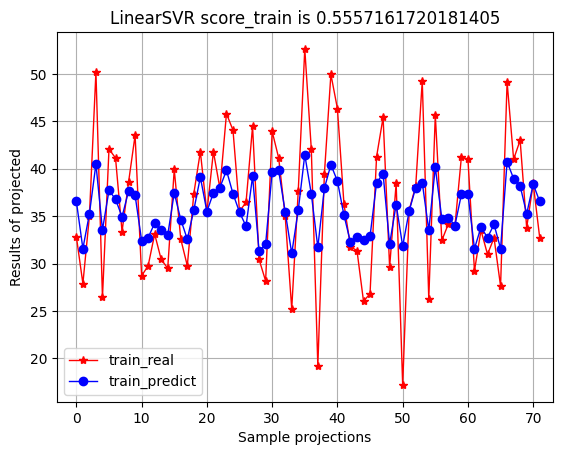

In [ ]:
#  绘图
plt.plot(range(0, M), t_train, 'r-*',linewidth=1, label='train_real')
plt.plot(range(0, M), predict1, 'b-o',linewidth=1,label='train_predict')
plt.legend('train_real', 'predict')
plt.xlabel('Sample projections')
plt.ylabel('Results of projected')
string = "SVM score_train is {}".format(score_train)
plt.title(string)
plt.xlim([-3, M+1])

plt.legend()
# 显示图形
plt.grid()
plt.show()

<ipython-input-49-0467accd13af>:4: UserWarning: The label '_' of '_' starts with '_'. It is thus excluded from the legend.
  plt.legend('test_real', 'test_predict')
<ipython-input-49-0467accd13af>:4: UserWarning: Legend does not support handles for str instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#controlling-the-legend-entries
  plt.legend('test_real', 'test_predict')


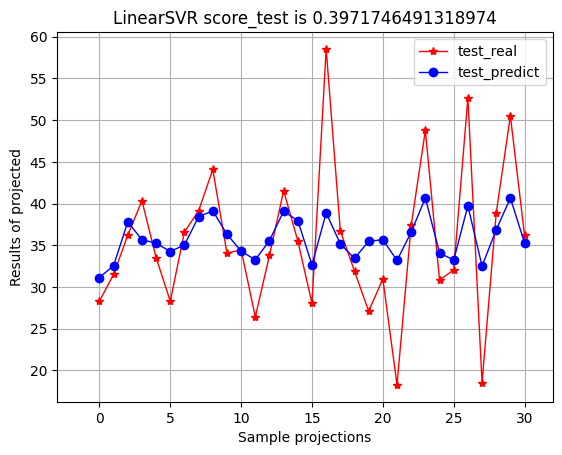

In [ ]:
#  绘图
plt.plot(range(0, N), t_test, 'r-*',linewidth=1, label='test_real')
plt.plot(range(0, N), predict2, 'b-o',linewidth=1,label='test_predict')
plt.legend('test_real', 'test_predict')
plt.xlabel('Sample projections')
plt.ylabel('Results of projected')
string = "SVM score_test is {}".format(score_test)
plt.title(string)
plt.xlim([-3, N+1])
plt.legend()
# 显示图形
plt.grid()
plt.show()

In [ ]:
# R^2就等于 内置的score()函数
# 用来衡量模型拟合数据的程度，取值范围在0到1之间。R2越接近1，说明模型对数据的拟合度越高
R1 = 1 - np.linalg.norm(t_train - predict1) ** 2 / np.linalg.norm(t_train - np.mean(t_train)) ** 2 #训练集的R^2
R1

0.5557161720181405

In [ ]:
R2 = 1 - np.linalg.norm(t_test - predict2) ** 2 / np.linalg.norm(t_test - np.mean(t_test)) ** 2 #测试集的R^2
R2

0.3971746491318974

In [ ]:
# MAE
# 预测值与实际值之间差值的平均绝对值。MAE越小，说明模型的预测精度越高
MAE1 = np.sum(np.abs(predict1 - t_train)) / M #训练集的MAE
MAE1

3.722273919783215

In [ ]:
MAE2 = np.sum(np.abs(predict2 - t_test)) / N #测试集的MAE
MAE2

4.819561128736608

In [ ]:
# MBE
# MBE是预测值与实际值之间差值的平均值。MBE为0表示模型的预测结果没有偏差，否则表示存在偏差
MBE1 = np.sum(predict1 - t_train) / M #训练集的MBE
MBE1

-0.485948609183214

In [ ]:
# MBE
MBE2 = np.sum(predict2 - t_test) / N #测试集的MBE
MBE2

0.2821299808506661

In [ ]:
# MAPE
# MAPE是预测值与实际值之间百分比差值的平均绝对值
MAPE1 = np.sum(np.abs((predict1 - t_train) / t_train)) / M #训练集的MAPE
MAPE1

0.1111113449574735

In [ ]:
MAPE2 = np.sum(np.abs((predict2 - t_test) / t_test)) / N #测试集的MAPE
MAPE2

0.15199609047015222

In [ ]:
# RMSE
# RMSE是预测值与实际值之间差值的平方的均值的平方根。RMSE越小，说明模型的预测精度越高
RMSE1 = np.sqrt(np.sum((predict1 - t_train) ** 2) / M)  # 训练集的RMSE
RMSE1

4.887858198767399

In [ ]:
RMSE2 = np.sqrt(np.sum((predict2 - t_test) ** 2) / M)  # 训练集的RMSE
RMSE2

4.466418989197011

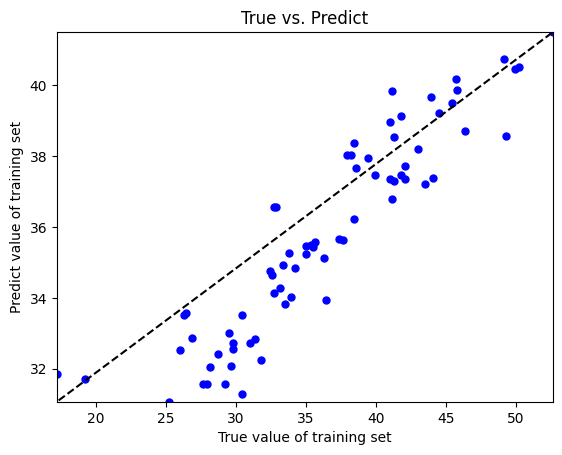

In [ ]:
# 绘制散点图
sz = 25
c = 'b'
plt.figure()
plt.scatter(t_train, predict1, sz, c)
plt.plot(plt.xlim(), plt.ylim(), '--k')
plt.xlabel('True value of training set')
plt.ylabel('Predict value of training set')
plt.xlim([min(t_train), max(t_train)])
plt.ylim([min(predict1), max(predict1)])
plt.title('True vs. Predict')
plt.show()

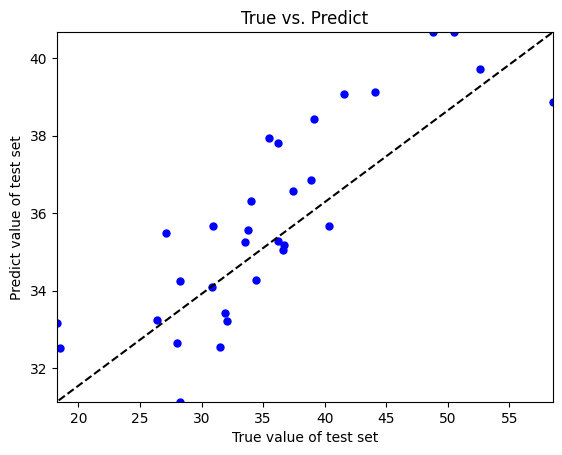

In [ ]:
plt.figure()
plt.scatter(t_test, predict2, sz, c)
plt.plot(plt.xlim(), plt.ylim(), '--k')
plt.xlabel('True value of test set')
plt.ylabel('Predict value of test set')
plt.xlim([min(t_test), max(t_test)])
plt.ylim([min(predict2), max(predict2)])
plt.title('True vs. Predict')
plt.show()

In [ ]:
print("训练集数据的R2为：{}".format(R1))
print("测试集数据的R2为：{}".format(R2))
print("训练集数据的MAPE为：{}".format(MAPE1))
print("测试集数据的MAPE为：{}".format(MAPE2))
print("训练集数据的MAE为：{}".format(MAE1))
print("测试集数据的MAE为：{}".format(MAE2))
print("训练集数据的MBE为：{}".format(MBE1))
print("测试集数据的MBE为：{}".format(MBE2))
print("训练集数据的RMSE为：{}".format(RMSE1))
print("测试集数据的RMSE为：{}".format(RMSE2))

训练集数据的R2为：0.5557161720181405
测试集数据的R2为：0.3971746491318974
训练集数据的MAPE为：0.1111113449574735
测试集数据的MAPE为：0.15199609047015222
训练集数据的MAE为：3.722273919783215
测试集数据的MAE为：4.819561128736608
训练集数据的MBE为：-0.485948609183214
测试集数据的MBE为：0.2821299808506661
训练集数据的RMSE为：4.887858198767399
测试集数据的RMSE为：4.466418989197011


In [ ]:
# 导入带预测的数据(未来数据)
df2 = pd.read_csv('data_predict.csv')
df2

,sym1,sym2,sym3,sym4,sym5,sym6,sym7,out1
0,273,82,105,210,9,904,680,NaN
1,163,149,191,180,12,843,746,NaN
2,162,148,191,179,16,840,743,NaN
3,162,148,190,179,19,838,741,NaN
4,154,112,144,220,10,923,658,NaN
5,147,89,115,202,9,860,829,NaN
6,152,139,178,168,18,944,695,NaN
7,145,0,227,240,6,750,853,NaN
8,152,0,237,204,6,785,892,NaN
9,304,0,140,214,6,895,722,NaN


In [ ]:
V_train = df2.iloc[:num_train_s, :f_]
V_train

,sym1,sym2,sym3,sym4,sym5,sym6,sym7
0,273,82,105,210,9,904,680
1,163,149,191,180,12,843,746
2,162,148,191,179,16,840,743
3,162,148,190,179,19,838,741
4,154,112,144,220,10,923,658
5,147,89,115,202,9,860,829
6,152,139,178,168,18,944,695
7,145,0,227,240,6,750,853
8,152,0,237,204,6,785,892
9,304,0,140,214,6,895,722


In [ ]:
predict3 = clf.predict(V_train)
print("预测结果：", predict3)

预测结果： [35.44663904 36.7926768  37.45304475 37.35105766 32.87602867 31.07155768
 36.84603988 35.03893141 34.13377868 38.3600488  32.5161814  32.65083355
 32.84736447 34.00989822 34.74646581 36.32182777 34.2504575  37.34206886
 38.54695778 31.57507707]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:432: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [ ]:
data = {'预测结果': predict3}
df3 = pd.DataFrame(data)
df3.to_csv('output.csv', index=False)